<p style="text-align:right;">Mario Stanke, Felix Becker, University of Greifswald, Germany</p>

# Exercise Set 3 - 1 - A <span style="color:red">Convolutional</span> Neural Network to Classify n-Gons

This notebook gives the first example of a *convolutional* neural network for the same data as before: **triangles, quadrilaterals, pentagons and hexagons.**

Step through and run all cells up to **Visualize the Filters** at the end. Follow the instructions there.

On your way, try to read and understand as much of the code as possible.

Remember that you can split cells with `CTRL` + `shift` + `-` anytime you want to check an intermediate result. Often that's the easiest way to understand what's going on.

(Don't worry to mess up the code, there is a way to revert back to default on request.)

In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Flatten, Conv2D, MaxPooling2D
import numpy as np
import pickle # to load 'pickled' numpy arrays (serialized, compressed)

2025-03-09 11:48:55.749728: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-09 11:48:55.749922: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-09 11:48:55.752558: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-09 11:48:55.787959: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-09 11:48:56.487312: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warnin

In [2]:
# load image data as numpy arrays (generated with a separate script available on request)
# Pickling is a way to store datastructures on a drive - or cucumbers in a glass.
# load training data
with open("../../data/ngons/ngon_train.pkl", "rb") as f:
    Xtrain, ytrain_class = pickle.load(f)
# load test data
with open("../../data/ngons/ngon_test.pkl", "rb") as f:
    Xtest, ytest_class = pickle.load(f)
    
Xtrain = np.expand_dims(Xtrain, -1)
Xtest = np.expand_dims(Xtest, -1)

num_train = Xtrain.shape[0]
num_test = Xtest.shape[0]
height = Xtrain.shape[1]
width = Xtrain.shape[2]
img_size_flat = width * height

print("Images are", width, "by", height, "pixels and have", Xtrain.shape[3], "color channel.")

num_classes = 4 # 0, 1, 2, 3 for 3-, 4-, 5-, 6-gons

# one-hot encode output classes
ytrain = np.eye(num_classes, dtype=float)[ytrain_class]
ytest = np.eye(num_classes, dtype=float)[ytest_class]
print("Fraction of classes:", np.mean(ytrain, axis=0)) # close to 1/4 each

# normalize input to [0,1]
Xtrain = Xtrain / 255.
Xtest = Xtest / 255.

print("Size of training set is", num_train, ", size of test set is", num_test)

# Number of classes
num_classes = 4 # 0, 1, 2, 3 for 3, ..., 6 gons


Images are 32 by 32 pixels and have 1 color channel.
Fraction of classes: [0.2567 0.2409 0.2502 0.2522]
Size of training set is 10000 , size of test set is 2000


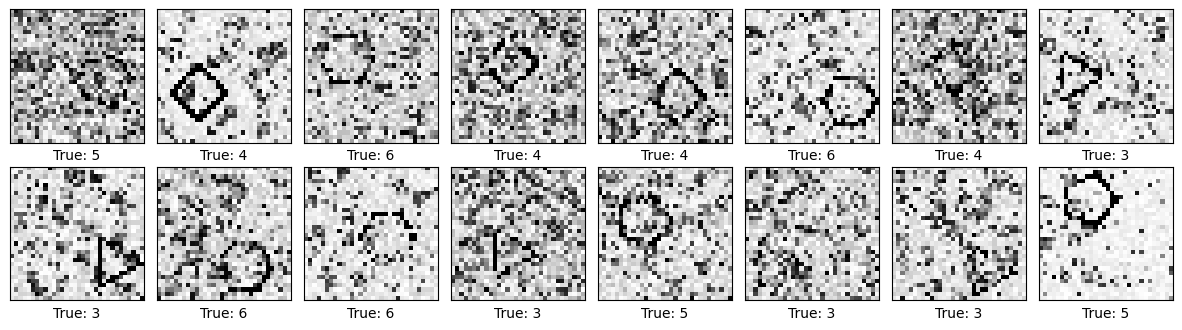

In [3]:
# Function to plot 8 images in a 2x4 grid, and writing the true and predicted classes below each image.
def plot_images(images, class_true, class_pred = None):
    """ Plot 16 (sample) images with their true and predicted classes"""
    assert len(images) == len(class_true) == 16

    # Create figure with sub-plots.
    fig, axes = plt.subplots(2, 8, figsize=(15, 4))
    fig.subplots_adjust(hspace=0.05, wspace=0.1)

    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i], interpolation = 'none', cmap = 'binary') # plot image

        # display also true and predicted classes
        if class_pred is None:
            xlabel = "True: {0}".format(3 + class_true[i])
        else:
            xlabel = "True: {0}, Pred: {1}".format(3 + class_true[i], 3 + class_pred[i])

        ax.set_xlabel(xlabel)

        # remove ticks from the plot
        ax.set_xticks([])
        ax.set_yticks([])


plot_images(Xtrain[0:16], ytrain_class[0:16])

## Create a Convolutional Neural Network Model


<img src="../cnn-ngon.png" alt="cnn architecture" width="800"/>



In [4]:
# Perform the neural network training and report the model, the training history and loss and accuracy on the test set.

model = tf.keras.models.Sequential()
model.add( Input(shape = (height, width, 1)))
model.add( Conv2D(filters = 8, kernel_size = (13, 13), input_shape = (height, width, 1)))
model.add( MaxPooling2D(pool_size = (20, 20)))
model.add( Conv2D(filters = 4, kernel_size = (1, 1),  activation = tf.nn.softmax))
model.add( Flatten())

model.summary()

# define the loss, optimization algorithm and prepare the model for gradient computation 
model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])

# execute the actual training
history = model.fit(Xtrain,
                    ytrain, epochs = 20,
                    validation_split = 0.2, verbose = 1,
                    batch_size = 64) # takes ~3m on CPU, a few seconds on a RTX 3090 GPU

/home/mario/.local/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-03-09 11:48:57.724593: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-03-09 11:48:57.725157: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and se

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 20, 20, 8)      │         1,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 1, 1, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 1, 1, 4)        │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,396 (5.45 KB)

 Trainable params: 1,396 (5.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4126 - loss: 1.2957 - val_accuracy: 0.8940 - val_loss: 0.8253
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9230 - loss: 0.7059 - val_accuracy: 0.9525 - val_loss: 0.4391
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9641 - loss: 0.3776 - val_accuracy: 0.9630 - val_loss: 0.2740
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9680 - loss: 0.2454 - val_accuracy: 0.9740 - val_loss: 0.1978
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9774 - loss: 0.1745 - val_accuracy: 0.9775 - val_loss: 0.1593
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9812 - loss: 0.1362 - val_accuracy: 0.9820 - val_loss: 0.1280
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9848 - loss: 0.1134 - val_accuracy: 0.9815 - val_loss: 0.1096
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9864 - loss: 0.0954 - val_accuracy: 0.

In [5]:
test_loss, test_acc  = model.evaluate(Xtest, ytest, verbose = 0)
print("Loss on test set:", test_loss, "\nAccuracy on test set:", test_acc)

Loss on test set: 0.03806690871715546 
Accuracy on test set: 0.9919999837875366


### Plot the training history

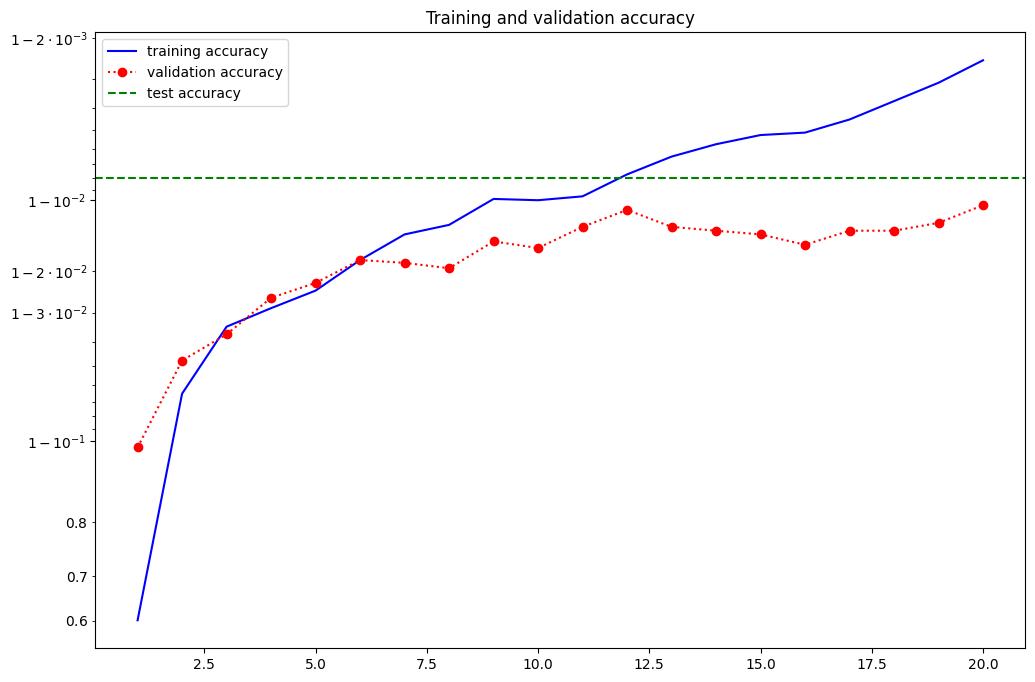

In [6]:
fig, ax = plt.subplots(figsize = (12, 8))

ax.set_title('Training and validation accuracy')

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(acc) + 1)
ax.set_yscale('logit')


ax.plot(epochs, acc, color = "blue", label = "training accuracy")
ax.plot(epochs, val_acc, "o:", color = "red", label = "validation accuracy")
ax.axhline(y = test_acc, color = "green", linestyle = "--", label = "test accuracy")

ax.legend();

From above plot we see that the model classifies training data siginifantly better than test data (overfit). It indicates that a model with fewer parameters or regularization could be better.

# Make and Examine Predictions

Predicted class probabilities for 3, 4, 5, 6 for the first 16 images:
 [[0.001 0.997 0.    0.001]
 [0.    0.    0.002 0.997]
 [0.999 0.    0.    0.   ]
 [0.    0.    0.    1.   ]
 [0.    1.    0.    0.   ]
 [0.    1.    0.    0.   ]
 [0.    0.    1.    0.   ]
 [0.    1.    0.    0.   ]
 [0.    0.    1.    0.   ]
 [0.    0.005 0.993 0.002]
 [1.    0.    0.    0.   ]
 [0.    0.    1.    0.   ]
 [1.    0.    0.    0.   ]
 [0.    1.    0.    0.   ]
 [0.025 0.703 0.093 0.178]
 [0.986 0.003 0.004 0.007]]


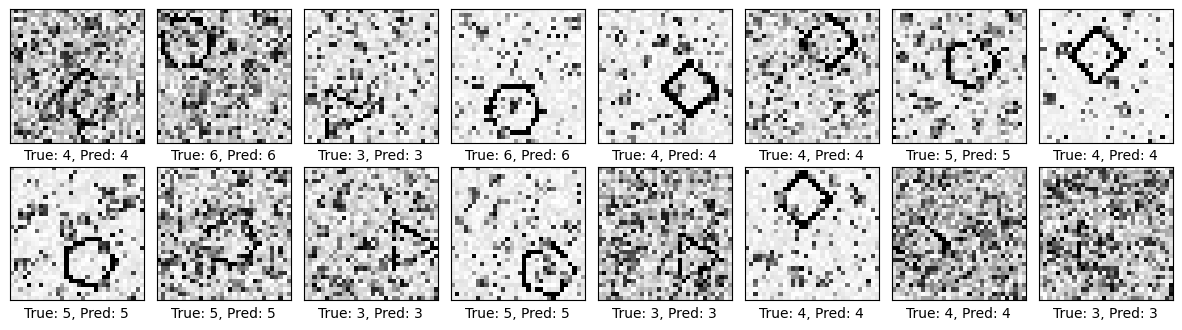

In [7]:
ytest_pred = model(Xtest)
print("Predicted class probabilities for 3, 4, 5, 6 for the first 16 images:\n", ytest_pred[0:16].numpy().round(3))

ytest_predclass = np.argmax(ytest_pred, axis = 1)
plot_images(Xtest[0:16], ytest_class[0:16], ytest_predclass[0:16])

# Visualize the Filters (your task)
Your task is to create a figure with 8 subplots (axes), one for each filter from the first layer.
Each subplot is a visualization of a $13 \times 13$ array of real numbers. This helps to understand, what patterns the filter respond to, at least in this very simple example.

In [8]:
# obtain the tensor of convolutional filters from the first layer 
Theta0 = model.get_weights()[0]
print(Theta0.shape)
# print the third filter as numbers
np.set_printoptions(linewidth = 100)
print(Theta0[:, :, 0, 2].round(3))

(13, 13, 1, 8)
[[-0.082  0.029 -0.052  0.015 -0.027  0.065  0.027 -0.069  0.401  0.336 -0.169 -0.155 -0.051]
 [-0.031 -0.002 -0.056 -0.012 -0.038 -0.096 -0.152  0.295  0.31   0.297  0.22  -0.139 -0.257]
 [-0.095 -0.004 -0.059 -0.108 -0.124 -0.213  0.297  0.465 -0.046  0.002  0.318  0.309 -0.15 ]
 [-0.045 -0.048 -0.127 -0.14  -0.131  0.423  0.5   -0.018  0.083  0.018 -0.043  0.356  0.298]
 [-0.088 -0.065 -0.286 -0.029  0.382  0.436  0.096 -0.018  0.004  0.012  0.059  0.066  0.377]
 [-0.063 -0.057 -0.079  0.431  0.453 -0.107 -0.018  0.035  0.06   0.005 -0.054  0.076  0.042]
 [-0.158  0.037  0.42   0.328 -0.105 -0.096  0.005 -0.055  0.076  0.044 -0.018 -0.03  -0.076]
 [-0.117  0.15   0.393  0.2   -0.102 -0.022  0.006 -0.099  0.023  0.102  0.028 -0.03   0.034]
 [ 0.054 -0.033 -0.156  0.367  0.379 -0.025  0.109 -0.005 -0.024 -0.041  0.061  0.114  0.069]
 [ 0.106 -0.13  -0.183 -0.134  0.355  0.336  0.038  0.05  -0.034 -0.006 -0.025  0.041  0.377]
 [-0.006 -0.064 -0.117 -0.112 -0.083  0.283  

Tips: 
 - [plt.imshow](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.imshow.html) automatically scales the pixel numbers to be between 0 and 1 using the minimum and maximum pixel value of the image (i.e. the brightest pixel of each image is always white and the darkest is always black).

In [9]:
# YOUR CODE HERE to create a plot of the filters, ~3 lines

If you are done and you've got yourself a GPU node, why not adjust the model architecture above a little bit and see if you can do something about the overfitting?